# 2.2 Matplotlib — Fundamentos

Matplotlib es la **biblioteca madre** de visualización en Python. Fue creada en 2003 por John Hunter y está inspirada en MATLAB. Todo en Python de visualización (Seaborn, Pandas plots, etc.) está construido sobre ella.

---

## 1.1 La arquitectura de Matplotlib

Matplotlib tiene una jerarquía de objetos:

```
Figure  (el lienzo completo — como una hoja de papel)
  └── Axes  (el área donde se dibuja — los ejes X e Y)
        ├── Axis  (el eje en sí: X o Y con sus ticks)
        ├── Line2D (líneas del gráfico)
        ├── Text  (títulos, etiquetas)
        └── Patch (rectángulos, círculos, áreas)
```

Entender esto es clave: siempre trabajas con una `Figure` que contiene uno o más `Axes`.

In [1]:
# ══════════════════════════════════════════════
# IMPORTACIONES FUNDAMENTALES
# ══════════════════════════════════════════════

import matplotlib.pyplot as plt
# matplotlib  → el paquete completo
# .pyplot     → submódulo con la interfaz de alto nivel (estilo MATLAB)
# as plt      → alias estándar en TODO el ecosistema Python

import numpy as np
# numpy       → biblioteca de arrays numéricos de alta performance
# as np       → alias estándar universal

import pandas as pd
# pandas      → tablas de datos (DataFrames), muy útil con Matplotlib
# as pd       → alias estándar

# Esta línea configura el tamaño predeterminado de TODAS las figuras
# [ancho, alto] en pulgadas — 1 pulgada ≈ 100 píxeles en pantalla
plt.rcParams['figure.figsize'] = [10, 5]

# Activa el renderizado de alta resolución en Jupyter
# %matplotlib inline  # ← descomenta si usas Jupyter clásico

print(f'Matplotlib versión: {plt.matplotlib.__version__}')
print(f'NumPy versión: {np.__version__}')

Matplotlib versión: 3.10.0
NumPy versión: 2.0.2


---

## 1.2 Tu primer gráfico — paso a paso

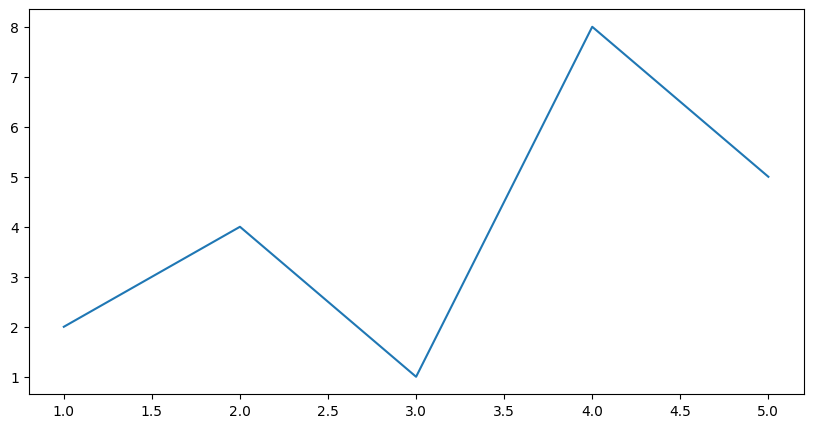

In [2]:
# ══════════════════════════════════════════════
# GRÁFICO MÁS SIMPLE POSIBLE
# ══════════════════════════════════════════════

# Paso 1: Crear datos
x = [1, 2, 3, 4, 5]    # Lista normal de Python — eje X
y = [2, 4, 1, 8, 5]    # Lista normal de Python — eje Y

# Paso 2: Llamar a plt.plot()
# plot(x, y) dibuja una línea conectando los puntos (x[0],y[0]), (x[1],y[1])...
plt.plot(x, y)

# Paso 3: Mostrar el gráfico
# En Jupyter se muestra automáticamente al final de la celda
# En scripts .py NECESITAS llamar plt.show() obligatoriamente
plt.show()

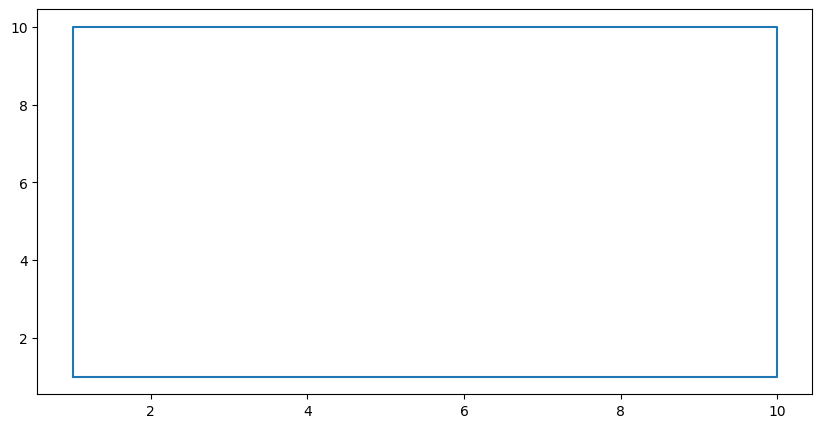

In [12]:
# ══════════════════════════════════════════════
# GRÁFICO MÁS SIMPLE POSIBLE
# ══════════════════════════════════════════════

# Paso 1: Crear datos
x = [1, 1,10,10,1]    # Lista normal de Python — eje X
y = [1, 10,10,1,1]    # Lista normal de Python — eje Y

# Paso 2: Llamar a plt.plot()
# plot(x, y) dibuja una línea conectando los puntos (x[0],y[0]), (x[1],y[1])...
plt.plot(x, y)

# Paso 3: Mostrar el gráfico
# En Jupyter se muestra automáticamente al final de la celda
# En scripts .py NECESITAS llamar plt.show() obligatoriamente
plt.show()

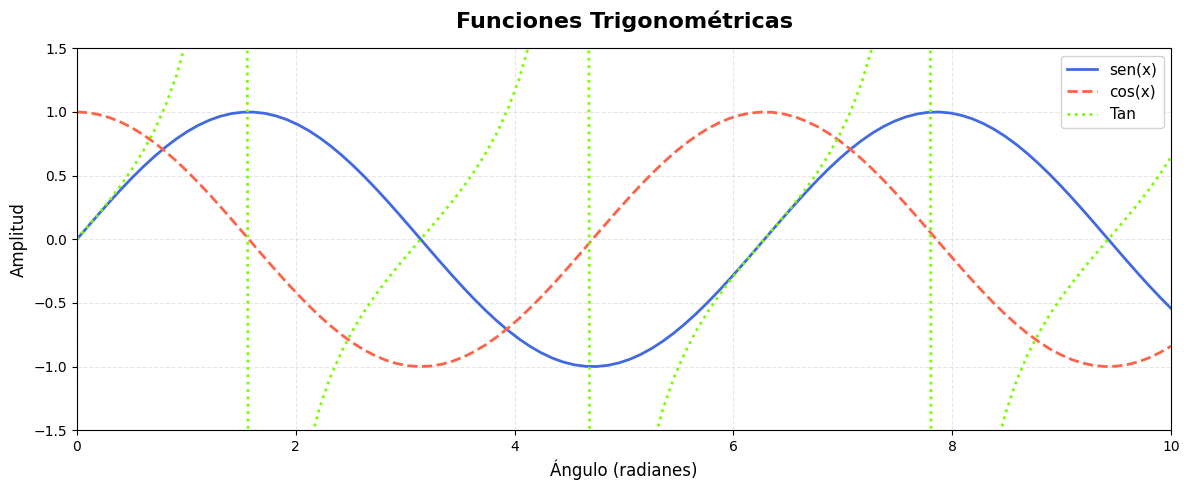

In [17]:
# ══════════════════════════════════════════════
# GRÁFICO CON TODOS LOS ELEMENTOS BÁSICOS
# ══════════════════════════════════════════════

# --- Generación de datos con NumPy ---

x = np.linspace(0, 10, 100)
# np.linspace(inicio, fin, cantidad_de_puntos)
# Genera 100 números IGUALMENTE ESPACIADOS entre 0 y 10
# Resultado: [0.0, 0.101, 0.202, ..., 10.0]

y_seno  = np.sin(x)    # sin() de cada elemento del array x
y_coseno = np.cos(x)   # cos() de cada elemento del array x
y_tan=np.tan(x)
# --- Creación de la figura ---

plt.figure(figsize=(12, 5))
# figure()   → crea una nueva figura vacía (el "lienzo")
# figsize    → (ancho, alto) en pulgadas
# Si no llamas figure(), plt usa la figura anterior o crea una automáticamente

# --- Trazado de líneas ---

plt.plot(x, y_seno,
         color='royalblue',   # color de la línea (nombre, hex '#1234ab', o RGB)
         linewidth=2,         # grosor de la línea en puntos
         linestyle='-',       # estilo: '-' sólida, '--' discontinua, ':' punteada, '-.' punto-raya
         label='sen(x)')      # etiqueta para la leyenda

plt.plot(x, y_coseno,
         color='tomato',
         linewidth=2,
         linestyle='--',
         label='cos(x)')


plt.plot(x, y_tan,
         color='lawngreen',
         linewidth=2,
         linestyle=':',
         label='Tan')

# --- Etiquetas y título ---

plt.title('Funciones Trigonométricas',
          fontsize=16,        # tamaño de fuente en puntos
          fontweight='bold',  # grosor: 'normal', 'bold'
          pad=15)             # espacio entre el título y el gráfico (puntos)

plt.xlabel('Ángulo (radianes)',
           fontsize=12)       # etiqueta del eje X

plt.ylabel('Amplitud',
           fontsize=12)       # etiqueta del eje Y

# --- Leyenda ---
plt.legend(
    loc='upper right',   # ubicación: 'best', 'upper left/right', 'lower left/right', 'center'
    fontsize=11,
    framealpha=0.9)      # transparencia del fondo de la leyenda (0=transparente, 1=sólido)

# --- Cuadrícula ---
plt.grid(
    True,                # True = activar, False = desactivar
    alpha=0.3,           # transparencia de las líneas de la cuadrícula
    linestyle='--')      # estilo de las líneas de la cuadrícula

# --- Límites de los ejes ---
plt.xlim(0, 10)          # rango del eje X: de 0 a 10
plt.ylim(-1.5, 1.5)      # rango del eje Y: de -1.5 a 1.5

plt.tight_layout()       # ajusta automáticamente los márgenes para que nada se corte
plt.show()

---

## 1.3 La interfaz orientada a objetos (recomendada)

Hay **dos formas** de usar Matplotlib:

| Interfaz | Sintaxis | Cuándo usarla |
|---|---|---|
| **pyplot** (implícita) | `plt.plot()`, `plt.title()` | Scripts rápidos, exploración |
| **OO** (orientada a objetos) | `fig, ax = plt.subplots()` → `ax.plot()` | Producción, múltiples gráficos, mayor control |

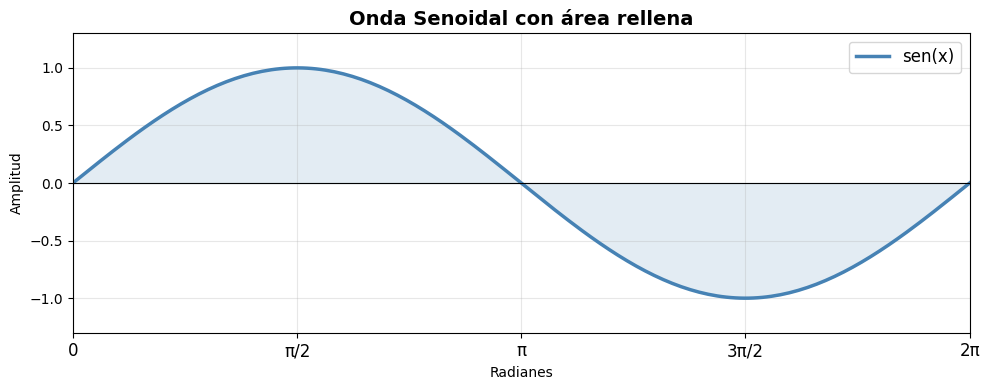

In [19]:
# ══════════════════════════════════════════════
# INTERFAZ ORIENTADA A OBJETOS (forma profesional)
# ══════════════════════════════════════════════

x = np.linspace(0, 2 * np.pi, 200)
# np.pi  → el número π (3.14159...)
# 2*π    → una vuelta completa en radianes
# 200    → 200 puntos para una curva muy suave

# plt.subplots() hace DOS cosas a la vez:
#   1. Crea una Figure (fig) — el contenedor de todo
#   2. Crea un Axes (ax)  — el área de dibujo con sus ejes
# Retorna una tupla (fig, ax) que desempacamos
fig, ax = plt.subplots(figsize=(10, 4))

# A partir de aquí todo se llama SOBRE ax, no sobre plt
# ax.plot() en lugar de plt.plot()
# ax.set_title() en lugar de plt.title()  ← nota el 'set_'

line, = ax.plot(x, np.sin(x),
                color='steelblue',
                linewidth=2.5,
                label='sen(x)')
# line,  → la coma desempaca la lista que retorna plot()
# 'line' es ahora un objeto Line2D que puedes modificar después

# Rellenar el área bajo la curva
ax.fill_between(
    x,              # eje X
    np.sin(x),      # límite superior del relleno
    0,              # límite inferior del relleno (el eje X)
    alpha=0.15,     # transparencia del relleno
    color='steelblue')

# Con la interfaz OO usamos set_* para configurar propiedades
ax.set_title('Onda Senoidal con área rellena', fontsize=14, fontweight='bold')
ax.set_xlabel('Radianes')
ax.set_ylabel('Amplitud')
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.3, 1.3)

# Personalizar los ticks (marcas) del eje X
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
# set_xticks() define DÓNDE van las marcas en el eje X

ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], fontsize=12)
# set_xticklabels() define QUÉ texto se muestra en cada marca

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
# axhline()  → dibuja una línea horizontal en y=valor específico
# Útil para marcar el cero o umbrales importantes

ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# fig.savefig()  → guarda la figura en un archivo
# fig.savefig('mi_grafico.png', dpi=150, bbox_inches='tight')
# dpi=150 → resolución (dots per inch). 72=pantalla, 150=calidad media, 300=impresión
# bbox_inches='tight' → recorta el espacio vacío alrededor

plt.tight_layout()
plt.show()

---

## 1.4 Gráfico de Barras

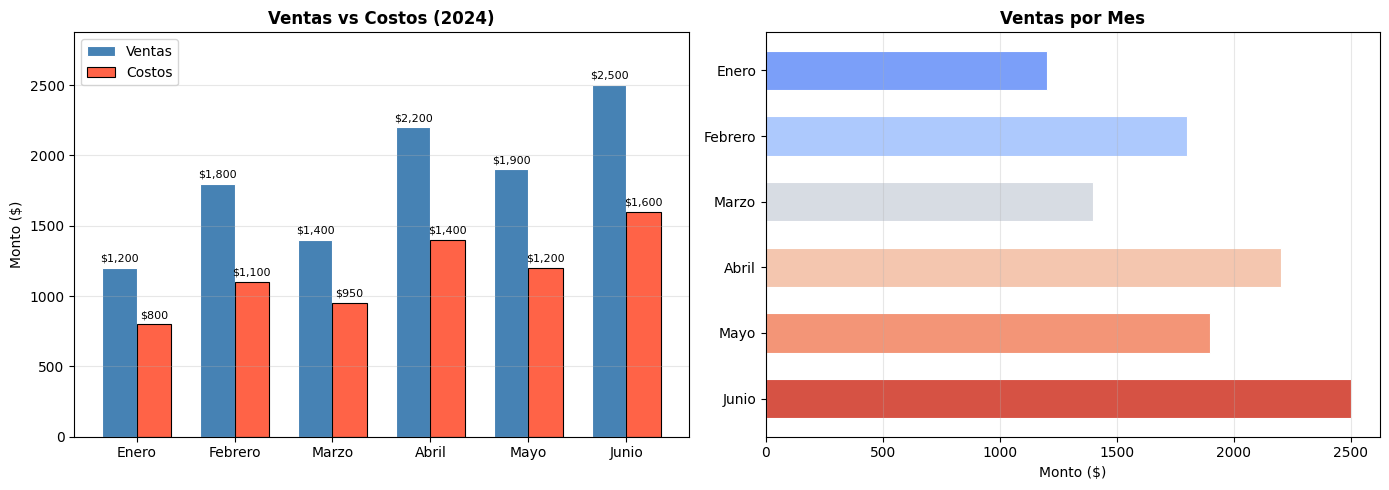

In [21]:
# ══════════════════════════════════════════════
# GRÁFICO DE BARRAS — vertical y horizontal
# ══════════════════════════════════════════════

categorias = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio']
ventas     = [1200, 1800, 1400, 2200, 1900, 2500]
costos     = [800,  1100, 950,  1400, 1200, 1600]

# Creamos posiciones numéricas para las barras
x = np.arange(len(categorias))
# np.arange(n)  → genera [0, 1, 2, 3, ..., n-1]
# Equivalente a range() pero retorna un array de NumPy

ancho = 0.35  # ancho de cada barra (el espacio total es 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# subplots(filas, columnas)  → crea una CUADRÍCULA de Axes
# (1, 2)  → 1 fila, 2 columnas = dos gráficos lado a lado
# axes    → ahora es un ARRAY de objetos Axes: axes[0] y axes[1]

# ── Gráfico izquierdo: barras verticales agrupadas ──
ax = axes[0]

bars1 = ax.bar(
    x - ancho/2,      # posición X de la barra (desplazada a la izquierda)
    ventas,            # altura de las barras
    ancho,             # ancho de las barras
    label='Ventas',
    color='steelblue',
    edgecolor='white', # color del borde de cada barra
    linewidth=0.8)

bars2 = ax.bar(
    x + ancho/2,       # posición X desplazada a la derecha
    costos,
    ancho,
    label='Costos',
    color='tomato',
    edgecolor='black',
    linewidth=0.8)

# Añadir etiquetas de valor encima de cada barra
def etiquetar_barras(ax, barras):
    for barra in barras:
        altura = barra.get_height()  # obtiene el valor (altura) de la barra
        ax.annotate(
            f'${altura:,}',           # texto a mostrar (formato con separador de miles)
            xy=(barra.get_x() + barra.get_width() / 2, altura),  # posición en el gráfico
            xytext=(0, 3),            # desplazamiento en píxeles desde xy
            textcoords='offset points',
            ha='center',              # alineación horizontal
            va='bottom',              # alineación vertical
            fontsize=8)

etiquetar_barras(ax, bars1)
etiquetar_barras(ax, bars2)

ax.set_title('Ventas vs Costos (2024)', fontweight='bold')
ax.set_xticks(x)                        # marcas en las posiciones 0,1,2,3,4,5
ax.set_xticklabels(categorias)          # texto de las marcas
ax.set_ylabel('Monto ($)')
ax.legend()
ax.grid(axis='y', alpha=0.3)            # grid solo en el eje Y (horizontal)
ax.set_ylim(0, max(ventas) * 1.15)     # 15% de espacio arriba para las etiquetas

# ── Gráfico derecho: barras horizontales ──
ax2 = axes[1]

colores = plt.cm.coolwarm(np.linspace(0.2, 0.9, len(categorias)))
# plt.cm         → módulo de mapas de color (colormaps)
# RdYlGn         → colormap Rojo-Amarillo-Verde
# np.linspace()  → 6 valores igualmente espaciados entre 0.2 y 0.9
# Esto asigna un color diferente a cada barra automáticamente

ax2.barh(
    categorias,    # eje Y (categorías)
    ventas,        # eje X (valores) → barras horizontales
    color=colores,
    edgecolor='white',
    linewidth=0.8,
    height=0.6)    # grosor de las barras horizontales (equivalente a 'width' en bar)

ax2.set_title('Ventas por Mes', fontweight='bold')
ax2.set_xlabel('Monto ($)')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()  # invertir el eje Y para que Enero quede arriba

plt.tight_layout()
plt.show()

---

## 1.5 Gráfico de Dispersión (Scatter Plot)

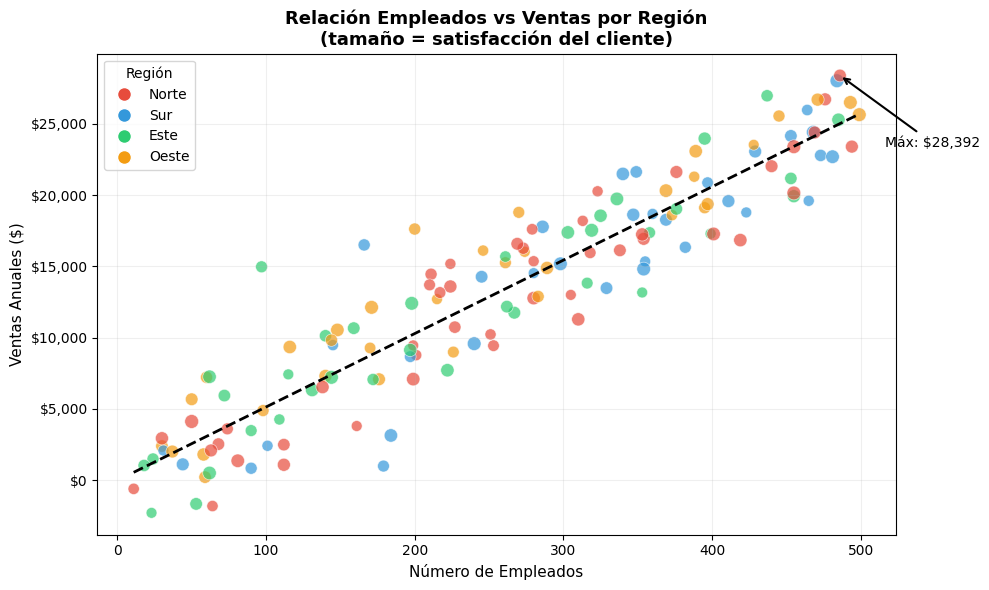

In [6]:
# ══════════════════════════════════════════════
# SCATTER PLOT — dispersión con color y tamaño
# ══════════════════════════════════════════════

np.random.seed(42)
# random.seed(42)  → fija la semilla del generador aleatorio
# Con la misma semilla, siempre obtendrás los MISMOS números aleatorios
# Fundamental para reproducibilidad científica
# El 42 no es especial, puedes usar cualquier entero

n = 150  # número de puntos

# Generamos datos simulados de una empresa: empleados, ventas, satisfacción y región
empleados    = np.random.randint(10, 500, n)          # enteros entre 10 y 500
ventas       = empleados * 50 + np.random.randn(n) * 3000  # correlación con ruido
# np.random.randn(n)  → n números con distribución normal estándar (media=0, std=1)
satisfaccion = np.random.uniform(60, 100, n)           # floats entre 60 y 100
region       = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], n)  # categorías

fig, ax = plt.subplots(figsize=(10, 6))

# Colores por categoría
colores_region = {'Norte': '#E74C3C', 'Sur': '#3498DB', 'Este': '#2ECC71', 'Oeste': '#F39C12'}
c = [colores_region[r] for r in region]  # lista de colores correspondiente a cada punto

scatter = ax.scatter(
    empleados,          # posición X de cada punto
    ventas,             # posición Y de cada punto
    c=c,                # color de cada punto (lista o array)
    s=satisfaccion,     # TAMAÑO de cada punto (en puntos²) — representa la satisfacción
    alpha=0.7,          # transparencia — útil cuando los puntos se superponen
    edgecolors='white', # borde blanco alrededor de cada punto
    linewidths=0.5)     # grosor del borde

# Línea de tendencia (regresión lineal) con NumPy
coeficientes = np.polyfit(empleados, ventas, deg=1)
# np.polyfit(x, y, grado)  → ajusta un polinomio de grado 'deg'
# deg=1  → línea recta (y = mx + b)
# Retorna [pendiente m, intercepto b]

polinomio = np.poly1d(coeficientes)
# np.poly1d()  → convierte los coeficientes en una función callable
# Así podemos llamar polinomio(x) para obtener y

x_linea = np.linspace(empleados.min(), empleados.max(), 100)
ax.plot(x_linea, polinomio(x_linea),
        color='black', linewidth=2, linestyle='--',
        label='Tendencia', zorder=5)
# zorder  → orden de dibujo (mayor = encima)
# Por defecto los puntos tienen zorder=1; con 5 la línea queda encima

# Leyenda manual para las regiones
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
           markersize=10, label=region_nombre)
    for region_nombre, color in colores_region.items()
]
# Line2D()  → crea un elemento de leyenda personalizado
# marker='o'  → círculo; color='w'  → línea blanca (invisible)
# Este truco crea solo el marcador sin la línea

ax.legend(handles=legend_elements, title='Región', loc='upper left')

# Anotación de un punto específico
idx_max = np.argmax(ventas)  # índice del valor máximo
ax.annotate(
    f'Máx: ${ventas[idx_max]:,.0f}',  # texto de la anotación
    xy=(empleados[idx_max], ventas[idx_max]),  # punto donde apunta la flecha
    xytext=(empleados[idx_max] + 30, ventas[idx_max] - 5000),  # posición del texto
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    # arrowstyle  → estilo de flecha: '->', '<-', '<->', '-|>', etc.
    fontsize=10, color='black')

ax.set_title('Relación Empleados vs Ventas por Región\n(tamaño = satisfacción del cliente)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Empleados', fontsize=11)
ax.set_ylabel('Ventas Anuales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
# FuncFormatter  → formatea los ticks con una función personalizada
# lambda x, p   → x=valor del tick, p=posición (no se usa aquí)
# f'${x:,.0f}'  → formato: $1,234,567

ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---

## 1.6 Histograma y Gráfico de Pastel

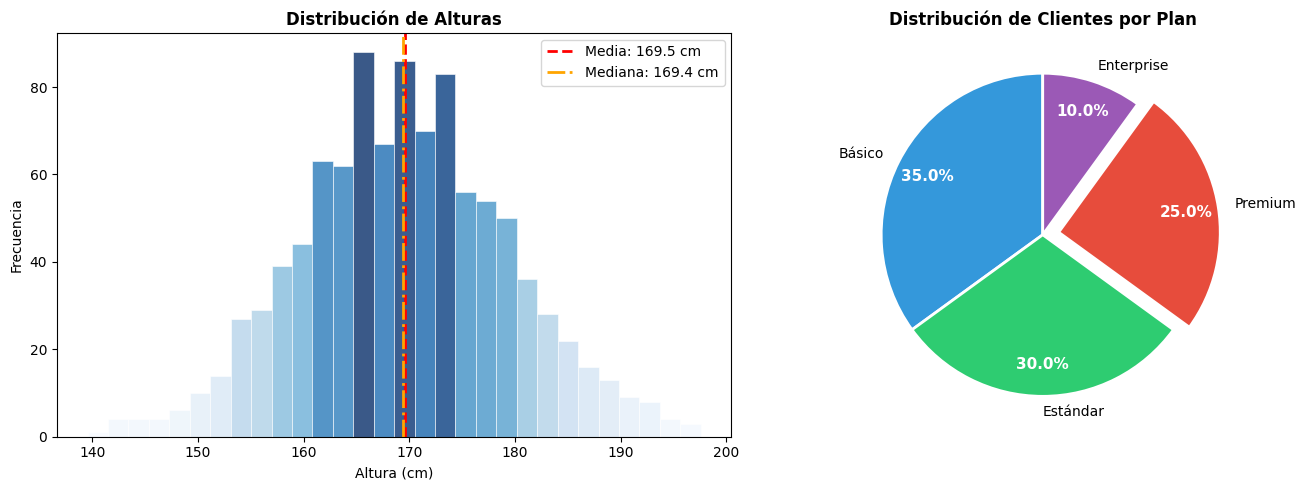

In [7]:
# ══════════════════════════════════════════════
# HISTOGRAMA y PIE CHART
# ══════════════════════════════════════════════

np.random.seed(0)
datos_normales = np.random.normal(loc=170, scale=10, size=1000)
# random.normal(loc, scale, size)
# loc=170    → media (valor central) — altura promedio en cm
# scale=10   → desviación estándar — cuánto varían los datos
# size=1000  → cantidad de muestras a generar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Desempacamos directamente: ax1 y ax2

# ── Histograma ──
n_hist, bins, patches = ax1.hist(
    datos_normales,
    bins=30,           # número de barras (bins) del histograma
                       # más bins = más detalle pero más ruido
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.8,
    density=False)     # density=True normaliza a densidad de probabilidad (suma=1)
# hist() retorna 3 cosas:
# n_hist   → alturas (frecuencias) de cada barra
# bins     → bordes de cada bin (tiene len(n)+1 elementos)
# patches  → objetos Rectangle de cada barra (para colorear individualmente)

# Colorear barras según su posición (mapa de color)
fracciones = (n_hist - n_hist.min()) / (n_hist.max() - n_hist.min())
# Normalizamos a [0, 1] para mapear colores
cmap = plt.cm.Blues
for fraccion, patch in zip(fracciones, patches):
    color = cmap(fraccion)          # obtiene el color del mapa para ese valor
    patch.set_facecolor(color)      # aplica el color a esa barra

# Línea de la media
ax1.axvline(x=datos_normales.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Media: {datos_normales.mean():.1f} cm')
# axvline()  → línea VERTICAL en x=valor
# :.1f       → formato de 1 decimal

ax1.axvline(x=np.median(datos_normales), color='orange', linestyle='-.',
            linewidth=2, label=f'Mediana: {np.median(datos_normales):.1f} cm')

ax1.set_title('Distribución de Alturas', fontweight='bold')
ax1.set_xlabel('Altura (cm)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# ── Gráfico de Pastel ──
etiquetas  = ['Básico', 'Estándar', 'Premium', 'Enterprise']
tamaños    = [35, 30, 25, 10]   # porcentajes (no necesitan sumar 100 exactamente)
colores_p  = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']
explosiones = [0, 0, 0.1, 0]
# explode    → cuánto se separa cada sector del centro
# 0.1        → el sector 'Premium' (índice 2) se separa un 10% del radio

wedges, texts, autotexts = ax2.pie(
    tamaños,
    labels=etiquetas,
    colors=colores_p,
    explode=explosiones,
    autopct='%1.1f%%',    # formato del porcentaje dentro de cada sector
                          # %1.1f → 1 dígito antes del punto, 1 decimal
    startangle=90,        # ángulo de inicio (90=arriba, 0=derecha)
    pctdistance=0.8,      # distancia del porcentaje al centro (0=centro, 1=borde)
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})  # borde blanco entre sectores

# wedges    → lista de Wedge (sectores)
# texts     → objetos Text de las etiquetas externas
# autotexts → objetos Text de los porcentajes internos

# Hacer los porcentajes internos en blanco y bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax2.set_title('Distribución de Clientes por Plan', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 1.7 Resumen de parámetros clave

| Parámetro | Valores posibles | Qué controla |
|---|---|---|
| `color` | `'red'`, `'#FF0000'`, `(1,0,0)`, `'C0'` | Color de línea/punto/barra |
| `linewidth` / `lw` | `0.5`, `1`, `2`, `5` | Grosor de línea |
| `linestyle` / `ls` | `'-'`, `'--'`, `':'`, `'-.'` | Estilo de línea |
| `marker` | `'o'`, `'s'`, `'^'`, `'*'`, `'+'` | Marcador en cada punto |
| `markersize` / `ms` | número | Tamaño del marcador |
| `alpha` | `0.0` a `1.0` | Transparencia |
| `label` | string | Texto en la leyenda |
| `zorder` | entero | Orden de superposición |